# 15 — Language

Grounding words in pixels, a tiny vision-language-action model, and an
agent that checks its work · SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/15-language/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** This week renders
    thousands of camera pictures through EGL, and that needs the GPU
    runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

It trains one small network on the CPU, about a minute.

## “Look at the green one.”

Four balls float in front of the G1. A person says a sentence. The robot
has to work out **which** ball the words mean, **where** it is in the
picture, and **what to do** about it — and then make sure it did.

That is the whole of Layer 5 in miniature: *what should the robot
achieve?*, asked in the language people actually use.

1.  Words become numbers; pixels become numbers; **attention** matches
    them.
2.  A 20,000-parameter vision-language-action model, trained in a
    minute.
3.  What it understood, and what it only appeared to.
4.  An **agent**: a sentence → a plan of skills → physics → a check
    after every step.

------------------------------------------------------------------------

## Setting up

In [1]:
import importlib.util

# On Colab, upgrade before importing: pip cannot replace a loaded module.
if importlib.util.find_spec("google.colab") is not None:
    %pip install -q --upgrade "soc4180[rl] @ git+https://github.com/gnoejh/soc4180.git"

import math, time
import numpy as np
import matplotlib.pyplot as plt
import torch
import soc4180          # first: it selects the GL backend before mujoco loads
import mujoco
from soc4180 import vision
from soc4180.render import _new_renderer

torch.manual_seed(0); torch.set_num_threads(4)
NAMES = ("red", "green", "blue", "yellow")
model = vision.camera_model(NAMES, radius=0.15)
print(f"{model.nmocap} balls: {', '.join(NAMES)}; one camera in the head")

4 balls: red, green, blue, yellow; one camera in the head

------------------------------------------------------------------------

## Colour code for the week

The same colours mean the same things in every equation on these slides:

| symbol | meaning | colour |
|------------------------|------------------------|------------------------|
| ${\color{#e8743b}{x,\ q}}$ | from the **words**: the bag of words $x$, and the query $q$ made from it | <span style="color:#e8743b">orange</span> |
| ${\color{#3b7dd8}{k_n}}$ | from the **pixels**: the key of picture cell $n$ | <span style="color:#3b7dd8">blue</span> |
| ${\color{#c0392b}{s_n}}$ | a **score**: how well cell $n$ answers the words | <span style="color:#c0392b">red</span> |
| ${\color{#2a9d5c}{p_n}}$ | a **probability**: the share of the heat on cell $n$ (they add to 1) | <span style="color:#2a9d5c">green</span> |
| ${\color{#8e44ad}{u_n,\ \hat u}}$ | a **position** in the picture: cell $n$’s centre, and the answer | <span style="color:#8e44ad">purple</span> |

$C = 32$ is the length of every key and of the query; there are
$N = 256$ cells (a 16 × 16 grid). Week 14’s picture coordinates
$u, v \in [-1, 1]$ and its formula `uv_of` are used again unchanged.

------------------------------------------------------------------------

## What a VLA is

**Vision-language-action** models — RT-2 (Google DeepMind, 2023),
OpenVLA (2024), π0 (Physical Intelligence, 2024) — take a camera picture
and an instruction and output robot actions:

|  | RT-2 / OpenVLA / π0 | today |
|------------------------|------------------------|------------------------|
| vision | a pretrained image transformer | 3 convolutions, trained here |
| language | a pretrained language model, billions of parameters | a bag of 19 words |
| how they meet | cross-attention inside a transformer | **one** attention step |
| action | tokens or a flow over joint commands | *where*, then a skill |
| training data | ~1 million robot episodes + the internet | 3,000 rendered pictures |
| parameters | 3–55 billion | **20,032** |

The shapes are the same. What changes is how much each part knew before
it ever saw a robot — and today we measure exactly what that buys.

------------------------------------------------------------------------

## The world, and its labels

3000 + 600 pictures in 5 s; labels (3000, 4, 2): every ball's (azimuth, elevation)

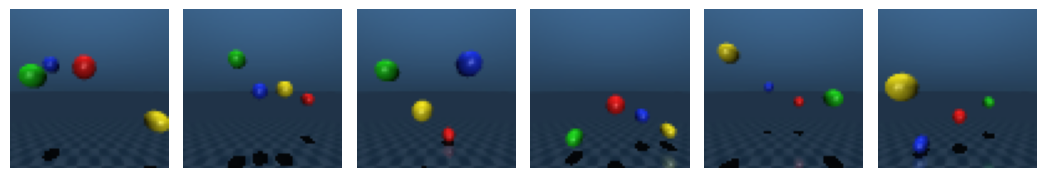

In [2]:
t0 = time.time()
X, Y = vision.render_dataset(model, 3000, seed=0, dist=(1.0, 2.5))
Xtest, Ytest = vision.render_dataset(model, 600, seed=1000, dist=(1.0, 2.5))
print(f"{len(X)} + {len(Xtest)} pictures in {time.time() - t0:.0f} s; labels {Y.shape}: every ball's (azimuth, elevation)")
fig, axes = plt.subplots(1, 6, figsize=(11, 2.1))
for ax, img in zip(axes, X[:6]):
    ax.imshow(img.transpose(1, 2, 0)); ax.axis("off")
fig.tight_layout(); plt.show()

The simulator knows where it put all four balls, so every picture comes
with four labels. A sentence picks one of them.

------------------------------------------------------------------------

## Words as numbers

In [3]:
TEMPLATES = ["point at the {c} ball", "look at the {c} one", "{c}", "find the {c} ball",
             "where is the {c} ball", "turn toward the {c} sphere", "show me {c}"]
vocab = vision.Vocab([t.format(c=c) for t in TEMPLATES for c in NAMES])
print(f"{len(vocab)} words: {', '.join(vocab.index)}")
print("bag('look at the green one') =", vocab.bag("look at the green one").int().tolist())
print("bag('the crimson ball')      =", vocab.bag("the crimson ball").int().tolist(), " <- 'crimson' lands in <unk>")

19 words: <unk>, point, at, the, red, ball, green, blue, yellow, look, one, find, where, is, turn, toward, sphere, show, me
bag('look at the green one') = [0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
bag('the crimson ball')      = [1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]  <- 'crimson' lands in <unk>

A **bag of words**: one slot per known word, counting how often it
appears. Order is lost — “red left of blue” and “blue left of red” are
the same bag — and an unknown word lands in the single `<unk>` slot,
indistinguishable from every other unknown word.

A real VLA replaces this with a language model’s *embedding*: each word
(or piece of one) becomes a vector learned from billions of sentences,
so “crimson” arrives already close to “red”.

------------------------------------------------------------------------

## A bag of words, worked

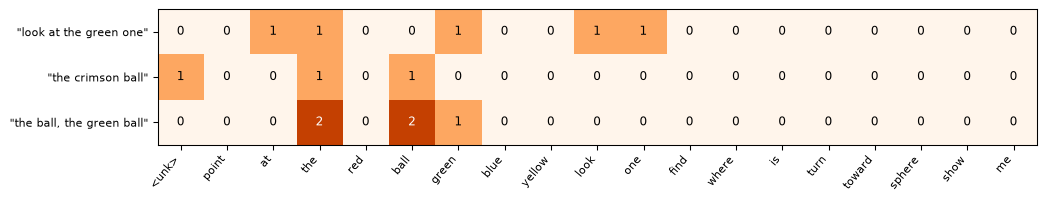

In [4]:
said = ["look at the green one", "the crimson ball", "the ball, the green ball"]
bags_demo = np.stack([vocab.bag(s).numpy() for s in said])
fig, ax = plt.subplots(figsize=(11, 2.2))
ax.imshow(bags_demo, cmap="Oranges", vmin=0, vmax=2.5, aspect="auto")
for (i, j), v in np.ndenumerate(bags_demo):
    ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=9, color="k" if v < 2 else "w")
ax.set_xticks(range(len(vocab))); ax.set_xticklabels(list(vocab.index), rotation=50, fontsize=8, ha="right")
ax.set_yticks(range(len(said))); ax.set_yticklabels([f'"{s}"' for s in said], fontsize=8)
fig.tight_layout(); plt.show()

**Step 1 — number the words.** `Vocab` reads the 28 training sentences
and gives every new word the next slot: `<unk>` 0, “point” 1, “at” 2,
“the” 3, “red” 4, … — 19 slots.

**Step 2 — count.** A sentence becomes
${\color{#e8743b}{x}} \in \mathbb{R}^{19}$ with ${\color{#e8743b}{x}}_w$
= how many times word $w$ appears. “look at the green one” puts a 1 in
each of its five slots. “the ball, the green ball” has **2** under “the”
and 2 under “ball” (punctuation is dropped). “the crimson ball” has a 1
under `<unk>`: every unknown word goes there, so “crimson”, “azure” and
“please” all look the same.

**Step 3 — notice what is lost.** The bag has no order and no grammar.
“The red ball left of the blue one” and “the blue ball left of the red
one” give the same 19 numbers.

------------------------------------------------------------------------

## From a bag to a query

The network turns the bag into its **query** with one linear layer
(`nn.Linear(19, 32)`): a $32 \times 19$ matrix $W$ and a bias $b$.

$${\color{#e8743b}{q}} = W\,{\color{#e8743b}{x}} + b
 = \sum_{w=0}^{18} {\color{#e8743b}{x}}_w\, W_{:,w} \;+\; b .$$

**Why the second form is the same thing:** multiplying a matrix by a
vector adds up the matrix’s columns, each weighted by the vector’s
entry. So

- each word $w$ owns one learned column $W_{:,w}$: 32 numbers, its
  **embedding**;
- a sentence’s query is the **sum of its words’ columns** (a word said
  twice counts twice), plus $b$;
- “look at the green one” $\to$
  ${\color{#e8743b}{q}} = W_{:,\text{look}} + W_{:,\text{at}} + W_{:,\text{the}} + W_{:,\text{green}} + W_{:,\text{one}} + b$.

That is what a real language model’s first layer does too — look up a
vector per word — except that there the vectors come pretrained, and
many more layers mix them so that order and grammar count.

------------------------------------------------------------------------

## Pixels as keys, words as a query

``` python
class HeatNet(nn.Module):                                   # soc4180.vision.HeatNet
    def __init__(self, nvocab, channels=32):
        self.keys = nn.Sequential(conv 3->32, relu, conv 32->32 stride 2, relu,
                                  conv 32->channels stride 2)          # 64x64 picture -> 16x16 grid
        self.query = nn.Linear(nvocab, channels)                        # the sentence -> one vector

    def forward(self, images, bags):
        k = self.keys(images).flatten(2)                     # B x C x 256 cells: a key per cell
        q = self.query(bags)                                 # B x C: the query
        return torch.einsum("bcn,bc->bn", k, q) / sqrt(C)    # a score per cell
```

$${\color{#c0392b}{s_n}} = \frac{{\color{#3b7dd8}{k_n}}\cdot {\color{#e8743b}{q}}}{\sqrt{C}}, \qquad
{\color{#2a9d5c}{p}} = \operatorname{softmax}({\color{#c0392b}{s}})$$

This is **attention** — the operation a transformer repeats billions of
times — with one query. The picture offers 256 keys (“here is something
greenish and round”), the sentence asks one question (“green?”), and the
dot product says which cells answer it.

The keys come from three convolutions (week 14):
$64 \to 64 \to 32 \to 16$ cells across, by the same output-size formula,
with $C = 32$ channels — so one 32-number key per cell of a 16 × 16
grid.

------------------------------------------------------------------------

## Attention, step by step

**Step 1 — score every cell.** For each of the $N = 256$ cells,
$${\color{#c0392b}{s_n}} = \frac{1}{\sqrt C}\sum_{c=1}^{C} {\color{#3b7dd8}{k_{n,c}}}\,{\color{#e8743b}{q_c}} .$$
A dot product is large when the two vectors point the same way: when the
cell has what the words ask for.

**Step 2 — turn scores into shares (softmax).**
$${\color{#2a9d5c}{p_n}} = \frac{e^{{\color{#c0392b}{s_n}}}}{\sum_{m=1}^{N} e^{{\color{#c0392b}{s_m}}}} .$$
The exponential makes every share positive; dividing by the total makes
them add to 1. Adding the same number to every score changes nothing (it
cancels top and bottom); only **differences** between scores matter, and
a score larger by 1 gets $e \approx 2.7$ times the share.

------------------------------------------------------------------------

## Attention: from shares to an answer

**Step 3 — the answer is the average position, weighted by the shares.**
With ${\color{#8e44ad}{u_n}}, {\color{#8e44ad}{v_n}}$ the centre of cell
$n$ in picture coordinates,
$${\color{#8e44ad}{\hat u}} = \sum_n {\color{#2a9d5c}{p_n}}\,{\color{#8e44ad}{u_n}}, \qquad
{\color{#8e44ad}{\hat v}} = \sum_n {\color{#2a9d5c}{p_n}}\,{\color{#8e44ad}{v_n}} .$$
This is the heat map’s **centre of mass** (`heat_to_uv`); it can land
between cell centres, so the answer is finer than the 16 × 16 grid.

**Step 4 — back to angles.** Week 14’s $u = -\tan a$,
$v = -\tan e/\cos a$ solved for $a$ and $e$ (`angles_of_uv`) turns
$({\color{#8e44ad}{\hat u}}, {\color{#8e44ad}{\hat v}})$ into the
azimuth the waist needs.

------------------------------------------------------------------------

## Attention with five cells, by hand

cell 0: key [0.1 0.9]  score  0.14  e^s   1.15  share 0.047  at u = -0.8
cell 1: key [0.3 0.2]  score  0.42  e^s   1.53  share 0.062  at u = -0.4
cell 2: key [2.  0.1]  score  2.83  e^s  16.92  share 0.685  at u = +0.0
cell 3: key [1. 0.]  score  1.41  e^s   4.11  share 0.166  at u = +0.4
cell 4: key [0.  0.5]  score  0.00  e^s   1.00  share 0.040  at u = +0.8
sum of e^s = 24.71;  answer u = sum of share x position = +0.037

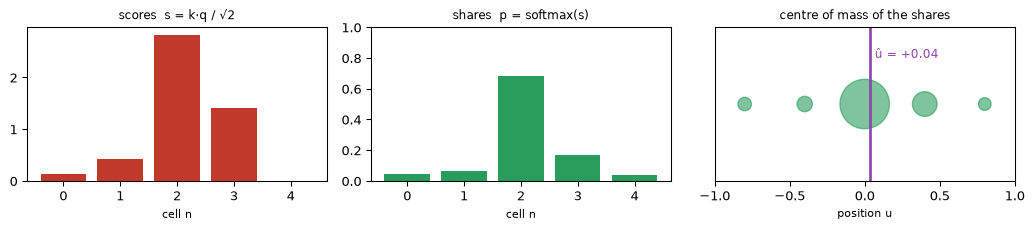

In [5]:
k5 = np.array([[0.1, 0.9], [0.3, 0.2], [2.0, 0.1], [1.0, 0.0], [0.0, 0.5]])   # C = 2: (redness, roundness)
q5 = np.array([2.0, 0.0])                                                      # the words ask: "red?"
u5 = np.array([-0.8, -0.4, 0.0, 0.4, 0.8])                                     # where each cell is
s5 = k5 @ q5 / np.sqrt(2)                                                      # Step 1
p5 = np.exp(s5) / np.exp(s5).sum()                                             # Step 2
uhat = (p5 * u5).sum()                                                         # Step 3
for n in range(5):
    print(f"cell {n}: key {k5[n]}  score {s5[n]:5.2f}  e^s {np.exp(s5[n]):6.2f}  share {p5[n]:.3f}  at u = {u5[n]:+.1f}")
print(f"sum of e^s = {np.exp(s5).sum():.2f};  answer u = sum of share x position = {uhat:+.3f}")

fig, axes = plt.subplots(1, 3, figsize=(11, 2.5))
axes[0].bar(range(5), s5, color="#c0392b"); axes[0].set_title("scores  s = k·q / √2", fontsize=9)
axes[1].bar(range(5), p5, color="#2a9d5c"); axes[1].set_title("shares  p = softmax(s)", fontsize=9); axes[1].set_ylim(0, 1)
for ax in axes[:2]:
    ax.set_xticks(range(5)); ax.set_xlabel("cell n", fontsize=8)
axes[2].scatter(u5, np.zeros(5), s=2000 * p5 + 10, color="#2a9d5c", alpha=0.6)
axes[2].axvline(uhat, color="#8e44ad", lw=2); axes[2].text(uhat + 0.03, 0.6, f"û = {uhat:+.2f}", color="#8e44ad", fontsize=9)
axes[2].set_xlim(-1, 1); axes[2].set_ylim(-1, 1); axes[2].set_yticks([]); axes[2].set_xlabel("position u", fontsize=8)
axes[2].set_title("centre of mass of the shares", fontsize=9)
fig.tight_layout(); plt.show()

Cell 2 has the reddest key, the biggest score (2.83), and — after the
exponential — about two-thirds of the heat. Cell 3, half as red, has a
score only 1.4 lower, but that is a factor $e^{1.4} \approx 4$ in share:
it gets about a sixth, and pulls the answer a little from 0 toward
itself. The softmax does not pick one cell; it **weights** them, which
is why the answer can land between cells.

------------------------------------------------------------------------

## Why divide by √C?

**The textbook argument.** Suppose the $C$ numbers in a key and in the
query are independent, with mean 0 and variance 1 (a transformer
normalises its features to roughly this).

**Step 1 — one product.** $E[k_c q_c] = E[k_c]\,E[q_c] = 0$, and
$\operatorname{Var}(k_c q_c) = E[k_c^2]\,E[q_c^2] = 1 \cdot 1 = 1$.

**Step 2 — a sum of $C$ of them.** Variances of independent terms add:
$\operatorname{Var}\big(\sum_c k_c q_c\big) = C$, so the raw dot product
has standard deviation $\sqrt C$ — **5.7 for $C = 32$**.

**Step 3 — divide by $\sqrt C$.**
$\operatorname{Var}\big(\tfrac{1}{\sqrt C}\sum_c k_c q_c\big) = C / C = 1$,
whatever $C$ is.

**Why the size of the scores matters:** a score larger by 1 gets 2.7
times the share; larger by 10, 22,000 times. Scores spread by 5.7 make
the softmax nearly **one-hot** before anything has been learned: the
network starts out confidently pointing at one arbitrary cell, and (*The
slope of cross-entropy*, below) the gradient then reaches only that cell
and the right one.

In [6]:
r = np.random.default_rng(0)
for C in (2, 32, 128):
    dots = (r.standard_normal((100000, C)) * r.standard_normal((100000, C))).sum(1)
    print(f"C = {C:3d}: std of k·q {dots.std():6.2f} (√C = {math.sqrt(C):5.2f});   std of k·q/√C {(dots / math.sqrt(C)).std():.3f}")
for spread in (1.0, math.sqrt(32)):
    s = r.standard_normal((2000, 256)) * spread
    p = np.exp(s - s.max(1, keepdims=True)); p /= p.sum(1, keepdims=True)
    print(f"256 scores spread {spread:4.2f}: biggest share on average {p.max(1).mean():.3f}   (all equal would be {1/256:.4f})")

C =   2: std of k·q   1.43 (√C =  1.41);   std of k·q/√C 1.009
C =  32: std of k·q   5.66 (√C =  5.66);   std of k·q/√C 1.001
C = 128: std of k·q  11.29 (√C = 11.31);   std of k·q/√C 0.998
256 scores spread 1.00: biggest share on average 0.043   (all equal would be 0.0039)
256 scores spread 5.66: biggest share on average 0.643   (all equal would be 0.0039)

------------------------------------------------------------------------

## …and what HeatNet’s scores actually are

The argument assumes unit-variance keys. Measure HeatNet’s, untrained
(the random-number state is saved and restored, so the network trained
on the next slides starts from exactly the same weights):

In [7]:
rng_state = torch.get_rng_state()
untrained = vision.HeatNet(len(vocab))
torch.set_rng_state(rng_state)
r = np.random.default_rng(9)
which = r.integers(len(NAMES), size=256)
bags0 = torch.stack([vocab.bag(f"look at the {NAMES[w]} ball") for w in which])
cells0 = torch.as_tensor(vision.cell_of(vision.uv_of(Y[np.arange(256), which, 0], Y[np.arange(256), which, 1]), 16))
with torch.no_grad():
    k0 = untrained.keys(vision.as_tensor(X[:256])).flatten(2); q0 = untrained.query(bags0)
    raw = torch.einsum("bcn,bc->bn", k0, q0)
    p0 = torch.softmax(raw / math.sqrt(32), -1)
    ce0 = torch.nn.functional.cross_entropy(raw / math.sqrt(32), cells0)
print(f"untrained: key std {k0.std():.3f}, query std {q0.std():.3f};  score std raw {raw.std():.3f}, divided by √C {(raw / math.sqrt(32)).std():.4f}")
print(f"biggest share on average {p0.max(1).values.mean():.4f} (1/256 = {1/256:.4f});   loss {ce0:.3f}  (ln 256 = {math.log(256):.3f})")

untrained: key std 0.045, query std 0.287;  score std raw 0.030, divided by √C 0.0052
biggest share on average 0.0039 (1/256 = 0.0039);   loss 5.544  (ln 256 = 5.545)

**Reading it.** HeatNet’s untrained keys are small (standard deviation
far below 1), so its scores are tiny **with or without** the $\sqrt C$:
every cell starts with the same share, $1/256$. The textbook reason does
not bite at the start here — and the unscaled version of this network
was found to train as well. The division is kept because it is what a
transformer does, and it keeps the scores’ size independent of $C$ if
you change it.

------------------------------------------------------------------------

## Softmax and cross-entropy, written out

*Where* is treated as **classification**: which of the 256 cells holds
the named ball? The label is one cell, $n^\ast$, from week 14’s `uv_of`:
column $= \lfloor 16\,(u+1)/2 \rfloor$, row
$= \lfloor 16\,(v+1)/2 \rfloor$,
$n^\ast = 16\cdot\text{row} + \text{column}$ (`cell_of`).

**Step 1 — the loss is minus the log of the right cell’s share:**
$$\text{CE} = -\log {\color{#2a9d5c}{p_{n^\ast}}} = -{\color{#c0392b}{s_{n^\ast}}} + \log\sum_{m} e^{{\color{#c0392b}{s_m}}} .$$
(Substitute Step 2’s softmax and use $\log(a/b) = \log a - \log b$.) It
is 0 if the right cell gets all the heat, and grows without limit as its
share goes to 0.

**Step 2 — read the numbers.** Untrained, every share is $1/256$ and
$\text{CE} = \ln 256 = 5.55$ — exactly what the last slide printed. A
loss of 0.53 means $e^{-0.53} = 0.59$: averaged (geometrically) over the
batch, the right cell holds 59% of the heat.

------------------------------------------------------------------------

## The slope of cross-entropy

$$\text{CE} = -{\color{#c0392b}{s_{n^\ast}}} + \log\sum_{m} e^{{\color{#c0392b}{s_m}}}$$

**Step 3 — the slope.** Differentiate Step 1 with respect to one score.
The first term gives $-1$ for the right cell only; the second gives
$e^{{\color{#c0392b}{s_n}}}/\sum_m e^{{\color{#c0392b}{s_m}}} = {\color{#2a9d5c}{p_n}}$:
$$\frac{\partial\,\text{CE}}{\partial {\color{#c0392b}{s_n}}} = {\color{#2a9d5c}{p_n}} - [\,n = n^\ast\,] .$$
Gradient descent therefore **raises the right cell’s score** by
$1 - {\color{#2a9d5c}{p_{n^\ast}}}$ and **lowers every other cell’s** by
its share. When the softmax is nearly one-hot on a wrong cell, only two
cells get a real push — the right one up, the favoured one down — and
the other 254 learn nothing from that example. That is why a softmax
should not start one-hot.

------------------------------------------------------------------------

## Training: cross-entropy on *where*

In [8]:
net = vision.HeatNet(len(vocab))
opt = torch.optim.Adam(net.parameters(), 2e-3)
rng = np.random.default_rng(0)

def batch(images, labels, templates, r):
    which = r.integers(len(NAMES), size=len(images))                 # one named ball per picture
    said = [templates[r.integers(len(templates))].format(c=NAMES[w]) for w in which]
    bags = torch.stack([vocab.bag(s) for s in said])
    return vision.as_tensor(images), bags, labels[np.arange(len(images)), which], said

t0 = time.time()
for epoch in range(10):
    img, bags, target, _ = batch(X, Y, TEMPLATES, rng)
    cells = torch.as_tensor(vision.cell_of(vision.uv_of(target[:, 0], target[:, 1]), net.grid))
    perm = torch.randperm(len(img))
    for i in range(0, len(img), 64):
        b = perm[i:i + 64]
        loss = torch.nn.functional.cross_entropy(net(img[b], bags[b]), cells[b])   # "which cell?" as classification
        opt.zero_grad(); loss.backward(); opt.step()
print(f"{sum(p.numel() for p in net.parameters()):,} parameters, 10 epochs in {time.time() - t0:.0f} s, "
      f"last loss {loss.item():.2f}")

20,032 parameters, 10 epochs in 32 s, last loss 0.53

*Where* is a classification over 256 cells — the label is the cell the
named ball is in. The answer read out afterwards is the heat map’s
centre of mass, which can land between cells.

------------------------------------------------------------------------

## The four steps on one real picture

scores from -49.0 to 4.9;  biggest share 0.512;  shares on the top 5 cells 1.000
answer (u, v) = (-0.438, +0.252)  ->  azimuth +23.6°, elevation -13.0°   (truth +24.2°, -12.9°)

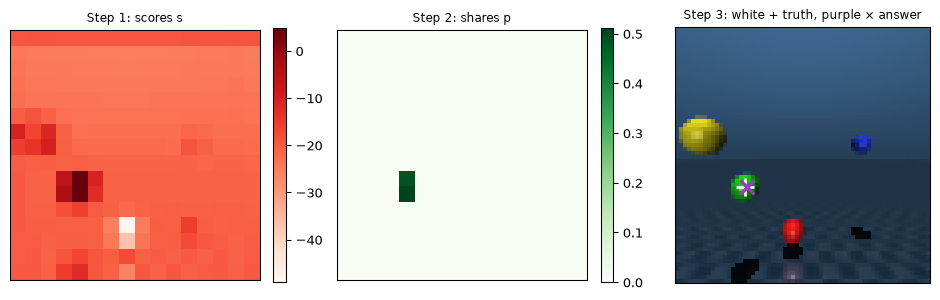

In [9]:
img = Xtest[3]
with torch.no_grad():
    k1 = net.keys(vision.as_tensor(img[None])).flatten(2)[0]           # C x 256: Step 1's keys
    q1 = net.query(vocab.bag("look at the green ball")[None])[0]        # C: the query
    s1 = (q1 @ k1) / math.sqrt(k1.shape[0])                             # Step 1: 256 scores
    p1 = torch.softmax(s1, -1)                                          # Step 2: 256 shares
uv1 = vision.heat_to_uv(s1[None], net.grid)[0]                          # Step 3: centre of mass
ang1, true1 = np.degrees(vision.angles_of_uv(uv1)), np.degrees(Ytest[3, NAMES.index("green")])
print(f"scores from {s1.min():.1f} to {s1.max():.1f};  biggest share {p1.max():.3f};  "
      f"shares on the top 5 cells {p1.sort(descending=True).values[:5].sum():.3f}")
print(f"answer (u, v) = ({uv1[0]:+.3f}, {uv1[1]:+.3f})  ->  azimuth {ang1[0]:+.1f}°, elevation {ang1[1]:+.1f}°   "
      f"(truth {true1[0]:+.1f}°, {true1[1]:+.1f}°)")
fig, axes = plt.subplots(1, 3, figsize=(10, 3.1))
im0 = axes[0].imshow(s1.reshape(16, 16).numpy(), cmap="Reds"); axes[0].set_title("Step 1: scores s", fontsize=9)
fig.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(p1.reshape(16, 16).numpy(), cmap="Greens"); axes[1].set_title("Step 2: shares p", fontsize=9)
fig.colorbar(im1, ax=axes[1], fraction=0.046)
axes[2].imshow(img.transpose(1, 2, 0))
tu, tv = vision.uv_of(*np.radians(true1))
axes[2].plot((tu + 1) * 32 - 0.5, (tv + 1) * 32 - 0.5, "+", color="w", ms=14, mew=2)
axes[2].plot((uv1[0] + 1) * 32 - 0.5, (uv1[1] + 1) * 32 - 0.5, "x", color="#8e44ad", ms=10, mew=2.5)
axes[2].set_title("Step 3: white + truth, purple × answer", fontsize=9)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()

The scores are no longer tiny: training has spread them over about 54
units (−49 to +5), so two neighbouring cells on the green ball stand far
above the rest and share almost all the heat — the top five cells hold
100% of it to three decimals. The centre of mass, pushed through week
14’s formula backwards, lands within a degree of the true direction.

------------------------------------------------------------------------

## What the words weigh

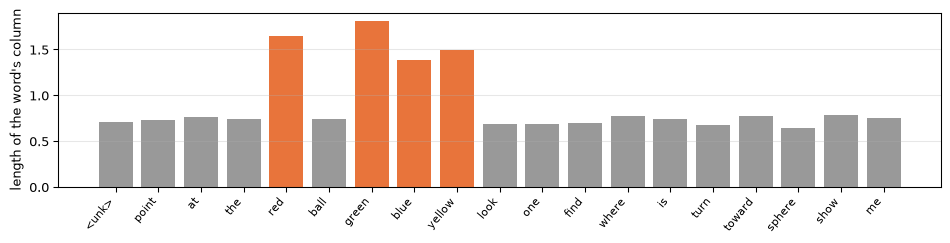

colour words: red 1.65, green 1.81, blue 1.39, yellow 1.49    every other word: 0.65 to 0.79

In [10]:
W = net.query.weight.detach().numpy()                   # 32 x 19: one column per word
norms = np.linalg.norm(W, axis=0)
words = list(vocab.index)
fig, ax = plt.subplots(figsize=(10, 2.6))
ax.bar(range(len(words)), norms, color=["#e8743b" if w in NAMES else "0.6" for w in words])
ax.set_xticks(range(len(words))); ax.set_xticklabels(words, rotation=50, ha="right", fontsize=8)
ax.set_ylabel("length of the word's column"); ax.grid(alpha=0.3, axis="y")
fig.tight_layout(); plt.show()
print("colour words:", ", ".join(f"{w} {norms[vocab.index[w]]:.2f}" for w in NAMES),
      f"   every other word: {min(norms[i] for w, i in vocab.index.items() if w not in NAMES):.2f}"
      f" to {max(norms[i] for w, i in vocab.index.items() if w not in NAMES):.2f}")

The query is the sum of the words’ columns (two slides back), so a
word’s column length says how hard it can pull the query. After training
the four colour words are about **twice** as long as every other word.
The other words are not switched off — they appear with every colour
equally, so they cannot say *which* ball, and the network learned to
lean on the words that can.

------------------------------------------------------------------------

## Four questions, one picture

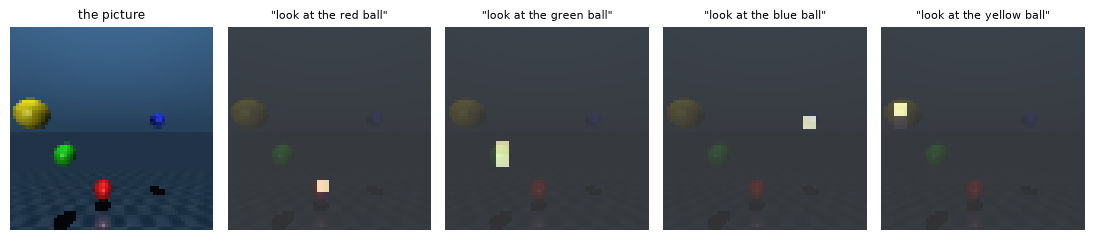

In [11]:
img = Xtest[3]
fig, axes = plt.subplots(1, 5, figsize=(11.5, 2.5))
axes[0].imshow(img.transpose(1, 2, 0)); axes[0].set_title("the picture", fontsize=9); axes[0].axis("off")
for ax, c in zip(axes[1:], NAMES):
    with torch.no_grad():
        heat = torch.softmax(net(vision.as_tensor(img[None]), vocab.bag(f"look at the {c} ball")[None]), -1)
    ax.imshow(img.transpose(1, 2, 0), alpha=0.45)
    ax.imshow(heat.reshape(net.grid, net.grid).numpy(), cmap="magma", alpha=0.65, extent=(-0.5, 63.5, 63.5, -0.5))
    ax.set_title(f'"look at the {c} ball"', fontsize=8); ax.axis("off")
fig.tight_layout(); plt.show()

Same picture, same keys; only the query changes, and the heat moves to a
different ball. Nothing in the network was told what “green” looks like
— it learned it because *green* in the sentence and the cell holding the
green ball kept appearing together.

------------------------------------------------------------------------

## What did it understand?

In [12]:
NEW = ["can you face the {c} ball please", "the {c} one, over there", "go {c}"]
def test(templates, label):
    img, bags, target, said = batch(Xtest, Ytest, templates, np.random.default_rng(5))
    with torch.no_grad():
        ang = vision.angles_of_uv(vision.heat_to_uv(net(img, bags), net.grid))
    e = np.degrees(np.linalg.norm(ang - target, axis=1))
    print(f"{label:32s} {e.mean():6.1f}°  {100 * np.mean(e < 5):5.0f}% within 5°   e.g. \"{said[0]}\"")
test(TEMPLATES, "phrasings it was trained on")
test(NEW, "new phrasings, known colours")
test(["point at the crimson ball"], "a colour word it never saw")
test(["point at the ball"], "no colour word at all")

phrasings it was trained on         2.0°     99% within 5°   e.g. "where is the blue ball"
new phrasings, known colours        2.1°     99% within 5°   e.g. "the blue one, over there"
a colour word it never saw         31.0°      7% within 5°   e.g. "point at the crimson ball"
no colour word at all              31.0°      6% within 5°   e.g. "point at the ball"

New sentences work *perfectly* — “can you face the green ball please”
was never in the data. That looks like understanding, and it is not: in
a bag of words the only informative words are the four colours, so any
sentence that contains one works; the unknown words (“can”, “please”)
all land in `<unk>`, and the known non-colour words pull the query about
half as hard as a colour (*What the words weigh*).

A colour word it never saw is **chance** — about 31°, the same as no
colour at all. There is no road from “crimson” to “red” in 3,000
pictures and 19 words. Pretraining on the internet is that road.

------------------------------------------------------------------------

## Confidently wrong

Hide the named ball behind the robot and ask for it anyway. Measured
over 200 pictures, half with the ball in view and half without:

| the named ball is    | heat-map peak, mean | … extreme        |
|----------------------|---------------------|------------------|
| in the picture       | 0.88                | lowest 0.42      |
| **behind the robot** | **0.60**            | **highest 0.98** |

The network was only ever shown pictures in which the ball was present,
so it has no way to say *“not here”*: it points at *something*, often
with full confidence. Its own output cannot be used to check itself.

So the agent checks with a **different, simpler sense**: the raw colour
of the pixels where the network points. If they are not green, whatever
the network believes, it is not looking at the green ball. Week 14 found
the same failure from the other side — the ball that left the picture.

------------------------------------------------------------------------

## From a sentence to a plan

``` python
def parse(instruction, synonyms=None, programs=None):          # soc4180.agent.parse
    text = apply synonyms word by word
    if a known phrase from `programs` is in the text: return its plan
    for clause in split on "and", "then", ",":
        "look/face/turn/point" -> ("look", clause)      "find/search" -> ("search", clause)
        "raise/wave/lift"      -> ("raise", side)  or ("raise_both",) if "both"
        "lower/drop"           -> ("lower", side)       anything else -> ("unknown", clause)
```

Each **skill** runs the physics and then **verifies** with a sensor:

| skill | does | checks |
|------------------------|------------------------|------------------------|
| `look(words)` | turns the waist, HeatNet in the loop (week 14’s servo) | the pixels where it points have that colour; within 5° of centre |
| `search(words)` | look; if the check fails, turn 60°, 60° the other way, 120° … | the same |
| `raise(side)` | shoulder to −150°, elbow straight (week 3’s WAVE) | hand above 1.2 m |
| `raise_both()` | both shoulders at once | hands above 1.2 m |
| every skill |  | pelvis above 0.6 m, tilt under 20° |

------------------------------------------------------------------------

## An agent, running

In [13]:
from soc4180 import agent
from pathlib import Path
torch.save({"state": net.state_dict(), "vocab": vocab.index}, "heatnet_lecture.pt")   # today's network
body = agent.Body()
eyes = agent.Eyes(body, "heatnet_lecture.pt")
for sentence in ("look at the green ball", "face the crimson ball", "raise both hands",
                 "raise your left hand then raise your right hand"):
    body.reset()
    plan = agent.parse(sentence)
    print(f'"{sentence}"  ->  {plan}')
    agent.run(body, eyes, plan)
Path("heatnet_lecture.pt").unlink()

"look at the green ball"  ->  [('look', 'look at the green ball')]
   look('look at the green ball',): ok -- green is in the middle of the picture (waist +10 deg)
"face the crimson ball"  ->  [('look', 'face the crimson ball')]
   look('face the crimson ball',): FAILED -- no colour I know in "face the crimson ball" (I know red, green, blue, yellow)
"raise both hands"  ->  [('raise_both',)]
   raise_both: FAILED -- fell over raising both arms at once
"raise your left hand then raise your right hand"  ->  [('raise', 'left'), ('raise', 'right')]
   raise('left',): ok -- left hand at 1.36 m
   raise('right',): ok -- right hand at 1.37 m

“Raise both hands” parses to the obvious plan, and the obvious plan
throws the robot on its face — week 3 found this with its hands. The
check catches it. The same goal as *left, then right* succeeds.
**Knowing what to do is not the same as knowing how**; the order is the
skill.

------------------------------------------------------------------------

## The agent loop, as pseudocode

What `agent.run` and the `look` skill do, with nothing left out but the
bookkeeping (pseudocode: it reads like Python but is not meant to run):

``` text
plan = parse(instruction)                   # words -> [("look", "the green ball"), ("raise", "left"), ...]
for skill, argument in plan:                # one step at a time, in order
    result = SKILLS[skill](body, eyes, argument)     # ACT: run the physics, then CHECK
    print(skill, "ok" if result.ok else "FAILED", result.message)
    if not result.ok:
        stop                                # a failed check ends the plan (a planner could re-plan here)

def look(body, eyes, words, gain=0.8):      # one skill, opened up
    colour = the colour word in `words`     # none?  -> FAILED "no colour I know"
    repeat for 2 s, every 0.1 s:            # PERCEIVE + ACT: week 14's servo loop
        a_hat = azimuth of HeatNet(picture, words)
        waist command += gain * a_hat
    CHECK, with senses other than HeatNet's own confidence:
        still standing?                     # pelvis above 0.6 m, tilt under 20 degrees
        pixels where HeatNet points have that colour?
        |a_hat| < 5 degrees?                # centred
    return ok / FAILED, with a message saying which check failed
```

Every skill ends by **measuring** whether it worked, and the loop reads
that measurement before going on. The next slide draws the same loop.

------------------------------------------------------------------------

## The loop

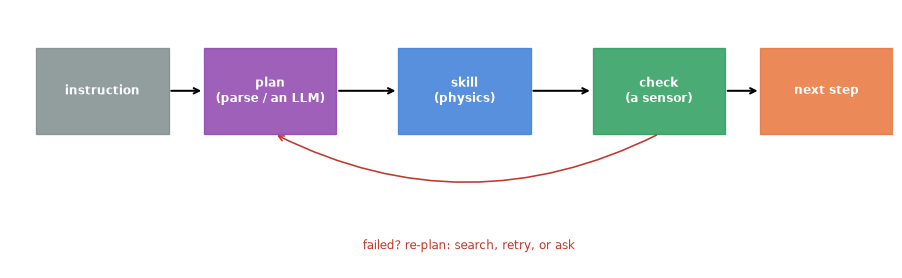

In [14]:
fig, ax = plt.subplots(figsize=(9.5, 3.0)); ax.axis("off"); ax.set_xlim(0, 10); ax.set_ylim(-0.3, 2.4)
boxes = [(0.3, "instruction", "#7f8c8d"), (2.2, "plan\n(parse / an LLM)", "#8e44ad"), (4.4, "skill\n(physics)", "#3b7dd8"),
         (6.6, "check\n(a sensor)", "#2a9d5c"), (8.5, "next step", "#e8743b")]
for x, label, c in boxes:
    ax.add_patch(plt.Rectangle((x, 1.1), 1.5, 0.9, color=c, alpha=0.85))
    ax.text(x + 0.75, 1.55, label, ha="center", va="center", color="w", fontsize=9, weight="bold")
for x0, x1 in ((1.8, 2.2), (3.7, 4.4), (5.9, 6.6), (8.1, 8.5)):
    ax.annotate("", xy=(x1, 1.55), xytext=(x0, 1.55), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.annotate("", xy=(3.0, 1.1), xytext=(7.35, 1.1), arrowprops=dict(arrowstyle="->", lw=1.2, color="#c0392b",
            connectionstyle="arc3,rad=-0.25"))
ax.text(5.2, -0.1, "failed? re-plan: search, retry, or ask", ha="center", fontsize=9, color="#c0392b")
fig.tight_layout(); plt.show()

**Perceive → plan → act → verify.** The checks are what make it an agent
rather than a script. Without them, a plan runs to the end whatever
happens: the robot “looks at the crimson ball” while staring at the
floor, and “raises both hands” from the floor.

------------------------------------------------------------------------

## Where a language model fits

The parser is the part a large language model replaces. Given the skills
as **tools**, it writes the plan — and it already knows that crimson is
red, that “hands up” means both, and that it cannot see behind itself:

``` python
# Not run here: it needs an API key and a network connection.
import anthropic
from soc4180 import agent
client = anthropic.Anthropic()
ball = {"type": "object", "properties": {"colour": {"enum": ["red", "green", "blue", "yellow"]}}, "required": ["colour"]}
arm = {"type": "object", "properties": {"side": {"enum": ["left", "right"]}}, "required": ["side"]}
tools = [{"name": "look", "description": "Turn the waist until the named ball is centred. Verifies by colour.", "input_schema": ball},
         {"name": "search", "description": "Turn and look until the named ball is found.", "input_schema": ball},
         {"name": "raise", "description": "Raise one arm overhead. Raising both at once topples the robot.", "input_schema": arm}]
body = agent.Body(); eyes = agent.Eyes(body, "checkpoints/heatnet.pt")
messages = [{"role": "user", "content": "Face the crimson ball, then hands up."}]
while True:
    reply = client.messages.create(model="claude-opus-5", max_tokens=16000, tools=tools, messages=messages)
    messages.append({"role": "assistant", "content": reply.content})
    if reply.stop_reason != "tool_use":
        break
    results = []
    for block in reply.content:
        if block.type == "tool_use":                         # run the skill; its check is the answer
            args = block.input.get("colour", block.input.get("side"))
            r = agent.SKILLS[block.name](body, eyes, f"the {args} ball" if block.name != "raise" else args)
            results.append({"type": "tool_result", "tool_use_id": block.id, "content": r.message,
                            "is_error": not r.ok})
    messages.append({"role": "user", "content": results})    # all results in one message
```

The skills, their checks and the loop stay exactly as they are. That
split — a model that plans in words, skills that act, sensors that
verify — is how most language-driven robot systems are built today
(SayCan, 2022; Code as Policies, 2022; and the agents built on the
current models).

------------------------------------------------------------------------

## Why the checks matter more with a better planner

A keyword parser fails loudly: it cannot read “crimson”, so it stops. A
language model fails **fluently**: it writes a plausible plan for
anything, including a plan whose second step topples the robot, or a
`look` at a ball that is not there.

| failure                          | who catches it                        |
|----------------------------------|---------------------------------------|
| a word the robot cannot ground   | the colour check (`look` fails)       |
| a plan that is physically unwise | the pelvis check (`raise_both` fails) |
| the named thing is out of sight  | the colour check, then `search`       |
| a skill that “succeeds” wrongly  | nothing — unless a check measures it  |

A robot acts in the world, and some actions cannot be undone. **The
cheaper and more general the planner, the more the verification has to
carry.**

------------------------------------------------------------------------

## The course, as one stack

| layer | what we built | weeks |
|------------------------|------------------------|------------------------|
| 1 Physics | MuJoCo, MJCF, contact, a timestep that can blow up | 0–1 |
| 2 Robot model | frames, FK, the body as a tree of numbers, sensors, a camera | 2–2b, 6, 14 |
| 4 Control | IK, LIPM walking, PD servos, filters, **MPPI** | 3–6, 11 |
| 5 Learning | MDPs, PPO, rewards, scale, **robustness, imitation** | 7–10, 12–13 |
| 5 Behaviour | **pixels, words, an agent that checks its work** | 14–15 |

Every layer was *measured*: nothing on these slides is a number someone
told us. The capstone is to add one more row.

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/15-language/lab_agent.py          # torch: uv sync --extra rl
uv run weeks/15-language/lab_agent.py --say "look at the red ball and raise your left hand"
```

A game: five instructions. **You edit only `instructions.py`**:
`SYNONYMS` (words the robot has never seen), `PROGRAMS` (whole plans for
a phrase), `SEARCH` (how to look for what is out of sight) and
`LOOK_GAIN`. `1`–`5` run an instruction and play it back, `G` grades all
five; `instructions.py` ships with blanks and scores 0 / 5.

| \# | Instruction | Needs |
|------------------------|------------------------|------------------------|
| 1 | “look at the green ball” | a gain that turns without falling |
| 2 | “face the crimson ball”, “look at the azure one” | two words grounded by hand |
| 3 | “raise both hands” | a plan that does not topple the robot |
| 4 | “find the yellow ball” (110° to the left) | a search that reaches it |
| 5 | look, raise, then find — one sentence | everything, in order |

------------------------------------------------------------------------

## Lab class: `ground.py`

``` bash
uv run weeks/15-language/ground.py
uv run weeks/15-language/ground.py --say "look at the green ball"
uv run weeks/15-language/ground.py --say "look at the crimson ball"
```

Renders the four-ball world, builds the vocabulary, trains HeatNet
(about 45 s), tests it on trained phrasings, new phrasings, an unknown
colour and no colour, then obeys `--say` with the waist and replays.

| Step | Does | Calls |
|------------------------|------------------------|------------------------|
| 1 | four balls, one camera | `vision.camera_model`, `render_dataset` |
| 2 | the vocabulary | `vision.Vocab`, `bag` |
| 3 | train | `vision.HeatNet`, `cross_entropy`, `cell_of`, `uv_of` |
| 4 | what it understood | `heat_to_uv`, `angles_of_uv` |
| 5 | obey | `Renderer(camera="head")`, `data.ctrl[waist]`, `mj_step`, `ball_direction` |

------------------------------------------------------------------------

## Exercises

1.  **Order matters.** Add the instruction “the ball left of the red
    one”. What does a bag of words make of it, and what would the
    network need?
2.  **A new colour.** Add a fifth, purple ball and the word “purple” to
    the templates. How many pictures does the network need to learn it?
3.  **Say “not here”.** Train HeatNet with a 257th cell meaning
    *absent*, on pictures where the named ball is behind the robot. Does
    the agent still need the colour check?
4.  **Synonyms for free.** Replace the bag of words with a pretrained
    word embedding (for instance GloVe vectors, downloaded once). Does
    “crimson” now work with no `SYNONYMS` entry?
5.  **An LLM planner.** With an API key, give the four skills to a
    language model as tools and run the five lab instructions. Which
    checks fire?

------------------------------------------------------------------------

## Capstone

Pick one layer and one number, and move it. Some that the course left
open:

- make the week-4 walker **turn**, and a student that imitates it;
- give PPO the **latency** of a real robot (week 12, exercise 3) and win
  back the margin it loses;
- a planner that also keeps the robot **where it was** after a 300 N
  shove (week 11);
- a camera that sees a ball **and a person**, and an instruction that
  uses both;
- anything else — with the number measured before and after.

Presentations in the final-exam slot.